# Perceptron trick
> Step VS Sigmoid fn

## Step function

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [78]:
from sklearn.datasets import make_classification
x,y = make_classification(n_samples = 160, 
                         n_features=2, 
                         n_informative=2, 
                         n_redundant=0, 
                         n_classes=2, 
                         n_clusters_per_class=1,
                         class_sep=10, 
                         random_state=41, 
                         hypercube=False)

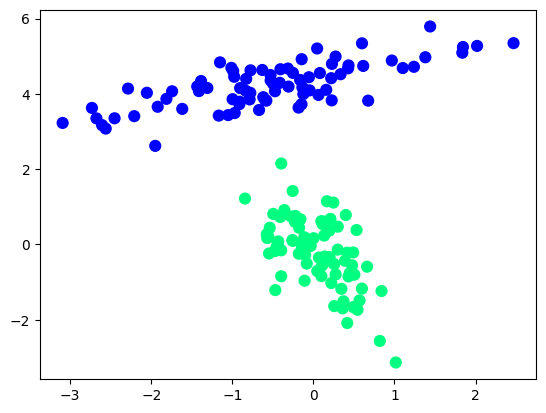

In [79]:
plt.scatter(x[:,0], x[:,1], c = y, cmap='winter',s = 60)

In [80]:
# step function
def step(z):
    if z > 0:
        return 1
    else:
        return 0
    

def perceptron(x,y):
    x = np.insert(x, 0, 1, axis = 1)
    weights = np.ones(x.shape[1]) # w0, w1, w2 -> 1,1,1
    lr = 0.09

    for i in range(1000):
        # random point selection
        j = np.random.randint(0, x.shape[0])
        y_pred = step(np.dot(x[j], weights))
        weights = weights + (lr * (y[j] - y_pred) * x[j])

    intercept = weights[0]  # w0
    coef = weights[1:] # w1, w2
    return intercept, coef

In [81]:
intercept_, coef_ = perceptron(x,y)

In [82]:
print(intercept_)
print(coef_)

1.1800000000000002
[ 0.16050578 -0.4761315 ]


In [83]:
# m = -w1 / w2
m = -coef_[0] / coef_[1]
# b = -w0 / w2
b = (-intercept_) / coef_[1]

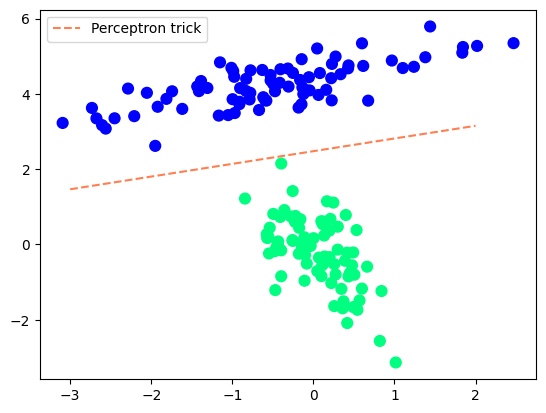

In [84]:
x_input = np.linspace(-3,2, 160)
y_input = m * x_input + b


plt.scatter(x[:,0], x[:,1], c = y, cmap='winter', s = 60)
plt.plot(x_input, y_input, color = 'coral', label = 'Perceptron trick', ls = 'dashed')
plt.legend()
# plt.grid(True)
plt.show()

## Sigmoid function

In [85]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [86]:
def perceptron_sigmoid(x,y):
    x = np.insert(x, 0, 1, axis = 1)
    weights = np.ones(x.shape[1]) # w0, w1, w2 -> 1,1,1
    lr = 0.09

    for i in range(1000):
        # random point selection
        j = np.random.randint(0, x.shape[0])
        y_pred = sigmoid(np.dot(x[j], weights))
        weights = weights + (lr * (y[j] - y_pred) * x[j])

    intercept = weights[0]  # w0
    coef = weights[1:] # w1, w2
    return intercept, coef

In [87]:
intercept, coef = perceptron_sigmoid(x,y)
print(intercept)
print(coef)

3.9849895695613733
[ 0.64793857 -2.0596043 ]


In [88]:
# m = -w1 / w2
m2 = -coef[0] / coef[1]
# b = -w0 / w2
b2 = (-intercept) / coef[1]

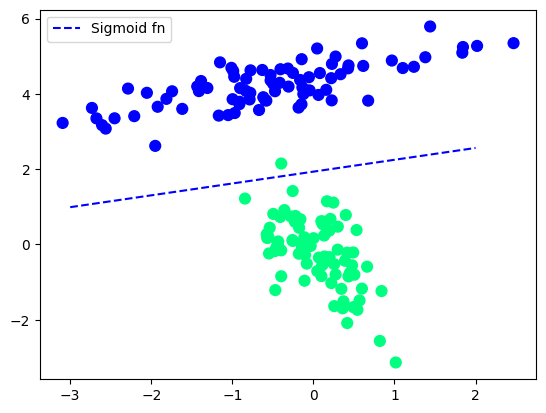

In [89]:
x_input2 = np.linspace(-3,2, 160)
y_input2 = m2 * x_input + b2


plt.scatter(x[:,0], x[:,1], c = y, cmap='winter', s = 60)
plt.plot(x_input2, y_input2, color = 'blue', label = 'Sigmoid fn', ls = 'dashed')
plt.legend()
# plt.grid(True)
plt.show()

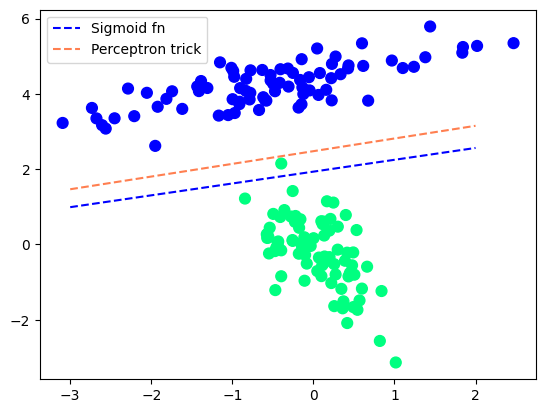

In [90]:
plt.scatter(x[:,0], x[:,1], c = y, cmap='winter', s = 60)
plt.plot(x_input2, y_input2, color = 'blue', label = 'Sigmoid fn', ls = 'dashed')
plt.plot(x_input, y_input, color = 'coral', label = 'Perceptron trick', ls = 'dashed')
plt.legend()
# plt.grid(True)
plt.show()